# UCSB Ridership Modeling Weekday: Analytical Summary and Interpretation

In [1]:
# Importing necessary package 
import pandas as pd 
import geopandas as gpd
import numpy as np
import os
import google.auth
import gcsfs
fs = gcsfs.GCSFileSystem()
from calitp_data_analysis.sql import get_engine
db_engine = get_engine()
credentials, project = google.auth.default()
pd.set_option('display.max_columns', None)

import statsmodels.api as sm
from scipy.stats import skew
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from shapely.geometry import Point

In [2]:
GCS_FILE_PATH = 'gs://calitp-analytics-data/data-analyses/ahsc_grant/ahsc_riderships/AHSC_2026'
with fs.open(f"{GCS_FILE_PATH}/stop_route_df.parquet", "rb") as f: 
    stop_route_df = gpd.read_parquet(f)

In [3]:
# Convert n_arrivals and n_routes to integer
stop_route_df['n_arrivals'] = stop_route_df['n_arrivals'].fillna(0).astype(int)
stop_route_df['n_routes'] = stop_route_df['n_routes'].fillna(0).astype(int)

In [4]:
# Copy the dataset
df = stop_route_df.copy()
y = df['average_daily_boardings']
df["log_arrivals"] = np.log(df["n_arrivals"] + 1)
X = df[['n_routes', 'log_arrivals',
        'total_pop_adj', 'workers_with_no_car_adj',  'total_youth_adj',  'total_seniors_adj', 'inc_total_lowincome_adj']]

# 4. Add intercept
X = sm.add_constant(X)

# Same X and y as  Poisson
nb_model_extended_final = sm.GLM(
    y,
    X,
    family=sm.families.NegativeBinomial()
).fit()

print(nb_model_extended_final.summary())

/home/jovyan/data-analyses/.venv/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                    Generalized Linear Model Regression Results                    
Dep. Variable:     average_daily_boardings   No. Observations:                21264
Model:                                 GLM   Df Residuals:                    21256
Model Family:             NegativeBinomial   Df Model:                            7
Link Function:                         Log   Scale:                          1.0000
Method:                               IRLS   Log-Likelihood:                -82793.
Date:                     Mon, 11 May 2026   Deviance:                       38268.
Time:                             18:34:44   Pearson chi2:                 2.85e+05
No. Iterations:                         51   Pseudo R-squ. (CS):             0.8306
Covariance Type:                 nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

In [5]:
# observed values
observed = df["average_daily_boardings"]

# predicted values from fixed-effects model
predicted = nb_model_extended_final.predict()

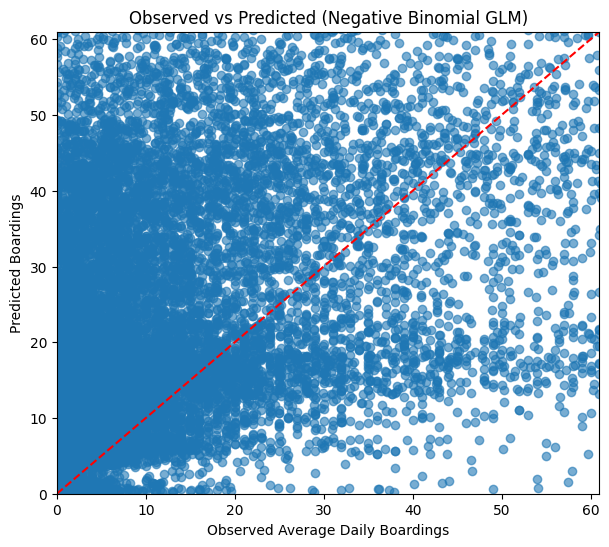

In [6]:
plt.figure(figsize=(7, 6))

plt.scatter(observed, predicted, alpha=0.6)

cap = np.percentile(np.concatenate([observed, predicted]), 90)

plt.plot([0, cap], [0, cap], color="red", linestyle="--")

plt.xlim(0, cap)
plt.ylim(0, cap)

plt.xlabel("Observed Average Daily Boardings")
plt.ylabel("Predicted Boardings")
plt.title("Observed vs Predicted (Negative Binomial GLM)")
plt.grid(False)

plt.show()

In [7]:
# SBMTD data 
feed_keys = ["dcc58c96c33532e549faf9bd89c8542d"]    
feed_keys_str = ", ".join(f"'{k}'" for k in feed_keys)

# Query only those feed_keys
with db_engine.connect() as connection:
    query = f"""
        SELECT 
            feed_key, stop_id, _feed_valid_from, n_hours_in_service, daily_arrivals,
            arrivals_early_am, arrivals_am_peak, arrivals_midday, 
            arrivals_pm_peak, arrivals_evening,
            route_id_array, route_type_array, stop_key, tts_stop_name,
            pt_geom, stop_name, location_type, stop_desc, stop_code
        FROM cal-itp-data-infra.mart_gtfs.fct_daily_scheduled_stops
        WHERE service_date = DATE('2026-05-05')
          AND feed_key IN ({feed_keys_str})
          AND ('28' IN UNNEST(route_id_array)
          OR '24X' IN UNNEST(route_id_array)
        OR '11' IN UNNEST(route_id_array)
        OR '15X' IN UNNEST(route_id_array)
        OR '27' IN UNNEST(route_id_array)
        )
    """
    df_feed = pd.read_sql(query, connection)

df_feed.head()

,feed_key,stop_id,_feed_valid_from,n_hours_in_service,daily_arrivals,arrivals_early_am,arrivals_am_peak,arrivals_midday,arrivals_pm_peak,arrivals_evening,route_id_array,route_type_array,stop_key,tts_stop_name,pt_geom,stop_name,location_type,stop_desc,stop_code
0,dcc58c96c33532e549faf9bd89c8542d,669,2026-04-30 03:00:01.083850+00:00,14,18,0,12,20,20,4,[15X],[3],fa4791e728076c1f348ea288cbb69497,None,POINT(-119.695892 34.409457),Castillo & Pershing Park,None,None,1086
1,dcc58c96c33532e549faf9bd89c8542d,17,2026-04-30 03:00:01.083850+00:00,14,38,0,12,30,28,4,[27],[3],82381a59b4772fdc3485a5e160292802,None,POINT(-119.856187 34.410741),Embarcadero & Sabado Tarde,None,None,1054
2,dcc58c96c33532e549faf9bd89c8542d,577,2026-04-30 03:00:01.083850+00:00,14,38,0,12,30,28,4,[27],[3],ace4501aacc7cc4014049f82071c69a4,None,POINT(-119.853462 34.41089),Ocean & Sabado Tarde,None,None,834
3,dcc58c96c33532e549faf9bd89c8542d,15,2026-04-30 03:00:01.083850+00:00,14,38,0,12,30,28,4,[27],[3],382b6a77ef2d0a8bd29fe88d035168cb,None,POINT(-119.857582 34.41187),Seville & Embarcadero Del Mar,None,None,1052
4,dcc58c96c33532e549faf9bd89c8542d,18,2026-04-30 03:00:01.083850+00:00,15,38,4,12,30,28,4,[27],[3],76b24f95f4a726a64073f85a704a7523,None,POINT(-119.856298 34.410651),Embarcadero & Sabado Tarde,None,None,1055


In [8]:
manual_coords = {
"San Benito Housing": (34.41949395025939, -119.85428516794293),
"UCSB North Hall Inbound": (34.41543823819993, -119.84793921762432),
"UCSB North Hall Outbound": (34.41528964133994, -119.84781297568064),
"UCSB Elings Hall Outbound": (34.41487045037956, -119.83962136296098),
}

In [9]:
def create_manual_df(manual_coords):
    rows = []

    for i, (stop_name, (lat, lon)) in enumerate(manual_coords.items(), start=1):
        rows.append({
            "stop_id": i,
            "stop_name": stop_name,
            "latitude": lat,
            "longitude": lon,
            "pt_geom": Point(lon, lat)
        })

    return pd.DataFrame(rows)

df_manual = create_manual_df(manual_coords)

In [10]:
# Convert your stops DataFrame to GeoDataFrame
gdf_29 = gpd.GeoDataFrame(df_manual, geometry='pt_geom', crs="EPSG:4326")

# Project to meters for accurate distance buffering (UTM Zone 11N for LA area)
gdf_29 = gdf_29.to_crs(epsg=32611)

buffer_distance = 404.672  # in meters
gdf_29['buffer'] = gdf_29.geometry.buffer(buffer_distance)

In [11]:
# Load the stored ACS dataset from the specified GCS file path.
with fs.open(f"{GCS_FILE_PATH}/census_tracts_data.parquet", "rb") as f:
    tracts_ca_acs = gpd.read_parquet(f)

acs_gdf = tracts_ca_acs.to_crs(gdf_29.crs)

In [12]:
geometry_intersect = gpd.overlay(acs_gdf, gdf_29.set_geometry('buffer'), how='intersection')

geometry_intersect['area_2'] = geometry_intersect.geometry.area  # area of overlap
geometry_intersect['area_ratio'] = geometry_intersect['area_2'] / geometry_intersect['area_m2']  # fraction

# Define demographic and socioeconomic columns to be adjusted by area ratio
cols_to_weight = [
    'total_pop', 'workers_with_no_car', 'total_youth', 'total_seniors', 'inc_total_lowincome']

for col in cols_to_weight:
    geometry_intersect[f'{col}_adj'] = geometry_intersect[col] * geometry_intersect['area_ratio']

In [13]:
agg = geometry_intersect.groupby(['stop_name']).agg({
    'total_pop_adj': 'sum',
    'workers_with_no_car_adj': 'sum',
    'total_seniors_adj': 'sum',
    'total_youth_adj': 'sum',
    'inc_total_lowincome_adj': 'sum'
})
 
gdf_29 = gdf_29.merge(
    agg,
    on=['stop_name'],
    how='left'
)

In [14]:
df_existing = df_feed.copy()

# convert string representation of list → actual list
df_existing['route_id_array_parsed'] = df_existing['route_id_array'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# compute number of unique routes
df_existing['n_routes'] = df_existing['route_id_array_parsed'].apply(
    lambda x: len(set(x)) if isinstance(x, list) else 0
)

In [15]:
df_existing_filtered = df_existing[
    df_existing['route_id_array'].astype(str).str.contains('28')
]

In [16]:
df_existing_filtered.head(24)

,feed_key,stop_id,_feed_valid_from,n_hours_in_service,daily_arrivals,arrivals_early_am,arrivals_am_peak,arrivals_midday,arrivals_pm_peak,arrivals_evening,route_id_array,route_type_array,stop_key,tts_stop_name,pt_geom,stop_name,location_type,stop_desc,stop_code,route_id_array_parsed,n_routes
24,dcc58c96c33532e549faf9bd89c8542d,161,2026-04-30 03:00:01.083850+00:00,18,75,4,30,60,58,24,"[28, 27]",[3],24d82dbb2438795d1c44dc23120ec16e,None,POINT(-119.86987 34.428296),Storke & Marketplace,None,None,281,"[28, 27]",2
83,dcc58c96c33532e549faf9bd89c8542d,511,2026-04-30 03:00:01.083850+00:00,18,70,6,36,60,56,42,"[11, 28]",[3],62f4538be92b899ba330177a28f38224,None,POINT(-119.8533 34.416898),El Colegio & Stadium,None,None,719,"[11, 28]",2
86,dcc58c96c33532e549faf9bd89c8542d,149,2026-04-30 03:00:01.083850+00:00,17,160,0,34,64,66,47,"[28, 24X, 27]",[3],b6ea8ac7c3faee08d0376599352d8458,None,POINT(-119.875665 34.428798),Santa Felicia & Marketplace,None,None,27,"[28, 24X, 27]",3
87,dcc58c96c33532e549faf9bd89c8542d,25,2026-04-30 03:00:01.083850+00:00,18,89,0,48,80,80,48,"[11, 28, 15X]",[3],a083c3021eeca55b8453d7eb9d4f08b7,None,POINT(-119.86543 34.417575),El Colegio & Camino Corto,None,None,1069,"[11, 28, 15X]",3
89,dcc58c96c33532e549faf9bd89c8542d,212,2026-04-30 03:00:01.083850+00:00,19,89,5,48,80,80,48,"[28, 15X, 11]",[3],6885eb64abce3700e8b30198e609c585,None,POINT(-119.8541 34.417475),El Colegio & Stadium,None,None,336,"[28, 15X, 11]",3
99,dcc58c96c33532e549faf9bd89c8542d,804,2026-04-30 03:00:01.083850+00:00,18,110,10,48,91,91,45,"[28, 2650, 27, 11, 2710]",[3],b7c9ac0ab926043edbad1a4eb0fccacd,None,POINT(-119.869891 34.419847),Storke & Sierra Madre,None,None,371,"[28, 2650, 27, 11, 2710]",5
100,dcc58c96c33532e549faf9bd89c8542d,597,2026-04-30 03:00:01.083850+00:00,18,110,10,48,91,95,45,"[28, 2650, 2710, 27, 11]",[3],fd8d47021b830ca14e16f772f83bc0aa,None,POINT(-119.86987 34.426371),Storke & Santa Felicia,None,None,877,"[28, 2650, 2710, 27, 11]",5
101,dcc58c96c33532e549faf9bd89c8542d,23,2026-04-30 03:00:01.083850+00:00,18,98,6,48,90,86,66,"[11, 24X, 28]",[3],2e0d78fc35be5ca73c2202a2249b7538,None,POINT(-119.85785 34.417241),El Colegio & Embarcadero Del Mar,None,None,1066,"[11, 24X, 28]",3
102,dcc58c96c33532e549faf9bd89c8542d,22,2026-04-30 03:00:01.083850+00:00,18,98,6,48,90,86,66,"[24X, 28, 11]",[3],c3b6173c81d32da05ccbae327760de26,None,POINT(-119.86115 34.417245),El Colegio & Los Carneros,None,None,1065,"[24X, 28, 11]",3
105,dcc58c96c33532e549faf9bd89c8542d,164,2026-04-30 03:00:01.083850+00:00,19,109,8,51,94,96,63,"[28, 90, 25, 24X, 27]",[3],dd9d07510c38d5a23f1eaa5ea8bf7403,None,POINT(-119.872498 34.42998),Hollister & Camino Real Marketplace,None,None,284,"[28, 90, 25, 24X, 27]",5


In [17]:
gdf_29.columns

Index(['stop_id', 'stop_name', 'latitude', 'longitude', 'pt_geom', 'buffer',
       'total_pop_adj', 'workers_with_no_car_adj', 'total_seniors_adj',
       'total_youth_adj', 'inc_total_lowincome_adj'],
      dtype='object')

In [18]:
df_merged = gdf_29.merge(
    df_existing[['stop_name', 'n_routes', 'daily_arrivals']],
    on='stop_name',
    how='left'
)

df_merged[['n_routes', 'daily_arrivals']] = (
    df_merged[['n_routes', 'daily_arrivals']].fillna(0)
)

In [19]:
df_merged

,stop_id,stop_name,latitude,longitude,pt_geom,buffer,total_pop_adj,workers_with_no_car_adj,total_seniors_adj,total_youth_adj,inc_total_lowincome_adj,n_routes,daily_arrivals
0,1,San Benito Housing,34.419494,-119.854285,POINT (237676.247 3812365.404),"POLYGON ((238080.919 3812365.404, 238078.970 3...",1902.740556,32.576209,6.802440,1702.797562,1539.695560,0.0,0.0
1,2,UCSB North Hall Inbound,34.415438,-119.847939,POINT (238246.997 3811899.058),"POLYGON ((238651.669 3811899.058, 238649.720 3...",1537.698689,0.000000,7.562065,1357.863327,1260.501738,3.0,62.0
2,3,UCSB North Hall Outbound,34.415290,-119.847813,POINT (238258.139 3811882.247),"POLYGON ((238662.811 3811882.247, 238660.863 3...",1543.667498,0.000000,7.591418,1363.134077,1265.394565,6.0,251.0
3,4,UCSB Elings Hall Outbound,34.414870,-119.839621,POINT (239009.950 3811814.601),"POLYGON ((239414.622 3811814.601, 239412.673 3...",560.612312,0.000000,2.756968,495.048155,459.552185,4.0,83.0


### Fall / Winter / Spring

Day: 12 × 4 = 48 arrivals
Evening: 4 × 2 = 8 arrivals

In [20]:
df_merged_fsw = df_merged.copy()

In [21]:
df_merged_fsw["n_routes_scn"] = df_merged_fsw["n_routes"] + 1
df_merged_fsw["daily_arrivals_scn"] = df_merged_fsw["daily_arrivals"] + 56

In [22]:
X_base_fsw= df_merged_fsw[[
    'n_routes',
    'daily_arrivals',
    'total_pop_adj',
    'workers_with_no_car_adj',
    'total_youth_adj',
    'total_seniors_adj',
    'inc_total_lowincome_adj',
]].fillna(0)

X_base_fsw = X_base_fsw.rename(columns={
    'n_routes': 'n_routes',
    'daily_arrivals': 'n_arrivals'
})

X_base_fsw["log_arrivals"] = np.log(X_base_fsw["n_arrivals"] + 1)

X_base_fsw= sm.add_constant(X_base_fsw)
X_base_fsw= X_base_fsw[nb_model_extended_final.model.exog_names]
df_merged_fsw['pred_baseline'] = nb_model_extended_final.predict(X_base_fsw)

In [23]:
X_scn_fsw = df_merged_fsw[[
    'n_routes_scn',
    'daily_arrivals_scn',
    'total_pop_adj',
    'workers_with_no_car_adj',
    'total_youth_adj',
    'total_seniors_adj',
    'inc_total_lowincome_adj',
]].copy()



X_scn_fsw = X_scn_fsw.rename(columns={
    'n_routes_scn': 'n_routes',
    'daily_arrivals_scn': 'n_arrivals'
    
})
X_scn_fsw["log_arrivals"] = np.log(X_scn_fsw["n_arrivals"] + 1)

X_scn_fsw  = sm.add_constant(X_scn_fsw)
X_scn_fsw  = X_scn_fsw[nb_model_extended_final.model.exog_names]
df_merged_fsw['pred_scenario'] = nb_model_extended_final.predict(X_scn_fsw)

In [24]:
df_merged_fsw['ridership_change'] = (
    df_merged_fsw['pred_scenario'] - df_merged_fsw['pred_baseline']
)

In [25]:
ridership_change_fsw= df_merged_fsw["ridership_change"].sum()
print(ridership_change_fsw)

341.67539178867486


### Summer

16 × 2 = 32 arrivals per day

In [26]:
df_merged_sum = df_merged.copy()

In [27]:
df_merged_sum["n_routes_scn"] = df_merged_sum["n_routes"] + 1
df_merged_sum["daily_arrivals_scn"] = df_merged_sum["daily_arrivals"] + 32

In [28]:
X_base_sum= df_merged_sum[[
    'n_routes',
    'daily_arrivals',
    'total_pop_adj',
    'workers_with_no_car_adj',
    'total_youth_adj',
    'total_seniors_adj',
    'inc_total_lowincome_adj',
]].fillna(0)

X_base_sum= X_base_sum.rename(columns={
    'n_routes': 'n_routes',
    'daily_arrivals': 'n_arrivals'
})

X_base_sum["log_arrivals"] = np.log(X_base_sum["n_arrivals"] + 1)

X_base_sum= sm.add_constant(X_base_sum)
X_base_sum= X_base_sum[nb_model_extended_final.model.exog_names]
df_merged_sum['pred_baseline'] = nb_model_extended_final.predict(X_base_sum)

In [29]:
X_scn_sum = df_merged_sum[[
    'n_routes_scn',
    'daily_arrivals_scn',
    'total_pop_adj',
    'workers_with_no_car_adj',
    'total_youth_adj',
    'total_seniors_adj',
    'inc_total_lowincome_adj',
]].copy()



X_scn_sum  = X_scn_sum .rename(columns={
    'n_routes_scn': 'n_routes',
    'daily_arrivals_scn': 'n_arrivals'
    
})
X_scn_sum["log_arrivals"] = np.log(X_scn_sum["n_arrivals"] + 1)

X_scn_sum  = sm.add_constant(X_scn_sum)
X_scn_sum  = X_scn_sum[nb_model_extended_final.model.exog_names]
df_merged_sum['pred_scenario'] = nb_model_extended_final.predict(X_scn_sum)

In [30]:
df_merged_sum['ridership_change'] = (
    df_merged_sum['pred_scenario'] - df_merged_sum['pred_baseline']
)

In [31]:
ridership_change_sum= df_merged_sum["ridership_change"].sum()
print(ridership_change_sum)

148.34520757542504


In [32]:
## Querying NTD Ridership Data for SMBTD

In [33]:
with db_engine.connect() as connection:
    query = """
        SELECT
            agency, ntd_id, reporter_type, report_year, primary_uza_name,
            unlinked_passenger_trips_upt, agency_voms
        FROM 
            cal-itp-data-infra.mart_ntd.dim_annual_service_agencies
        WHERE 
            state = 'CA'
            AND report_year = 2024
            AND agency IN (
                'Santa Barbara Metropolitan Transit District'
            )
    """
    ridership_data = pd.read_sql(query, connection)

In [34]:
ridership_data

,agency,ntd_id,reporter_type,report_year,primary_uza_name,unlinked_passenger_trips_upt,agency_voms
0,Santa Barbara Metropolitan Transit District,90020,Full Reporter,2024,"Santa Barbara, CA",4684415.0,71.0
